# 🗺️ 区域分析

**目标**：分析不同地区（Region → State → City）的销售表现，识别核心市场和潜力市场

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置 seaborn 样式
sns.set_style('whitegrid')
sns.set_palette('husl')

print('库加载完成！')

库加载完成！


In [2]:
# 加载数据
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# 转换日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f'数据加载成功！共 {len(df)} 条记录')

数据加载成功！共 9994 条记录


## 1. 区域（Region）维度分析

In [3]:
# 按区域聚合
region_stats = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Order ID': 'nunique',
    'Customer ID': 'nunique'
}).reset_index()

region_stats.columns = ['Region', 'Total Sales', 'Avg Sales', 
                        'Total Profit', 'Avg Profit', 'Orders', 'Customers']
region_stats['Profit Margin'] = (region_stats['Total Profit'] / region_stats['Total Sales'] * 100).round(2)
region_stats['Sales Share'] = (region_stats['Total Sales'] / region_stats['Total Sales'].sum() * 100).round(2)
region_stats = region_stats.sort_values('Total Sales', ascending=False)

print('='*60)
print('📊 区域销售数据')
print('='*60)
print(region_stats.to_string(index=False))

📊 区域销售数据
 Region  Total Sales  Avg Sales  Total Profit  Avg Profit  Orders  Customers  Profit Margin  Sales Share
   West  725457.8245 226.493233   108418.4489   33.849032    1611        686          14.94        31.58
   East  678781.2400 238.336110    91522.7800   32.135808    1401        674          13.48        29.55
Central  501239.8908 215.772661    39706.3625   17.092709    1175        629           7.92        21.82
  South  391721.9050 241.803645    46749.4303   28.857673     822        512          11.93        17.05


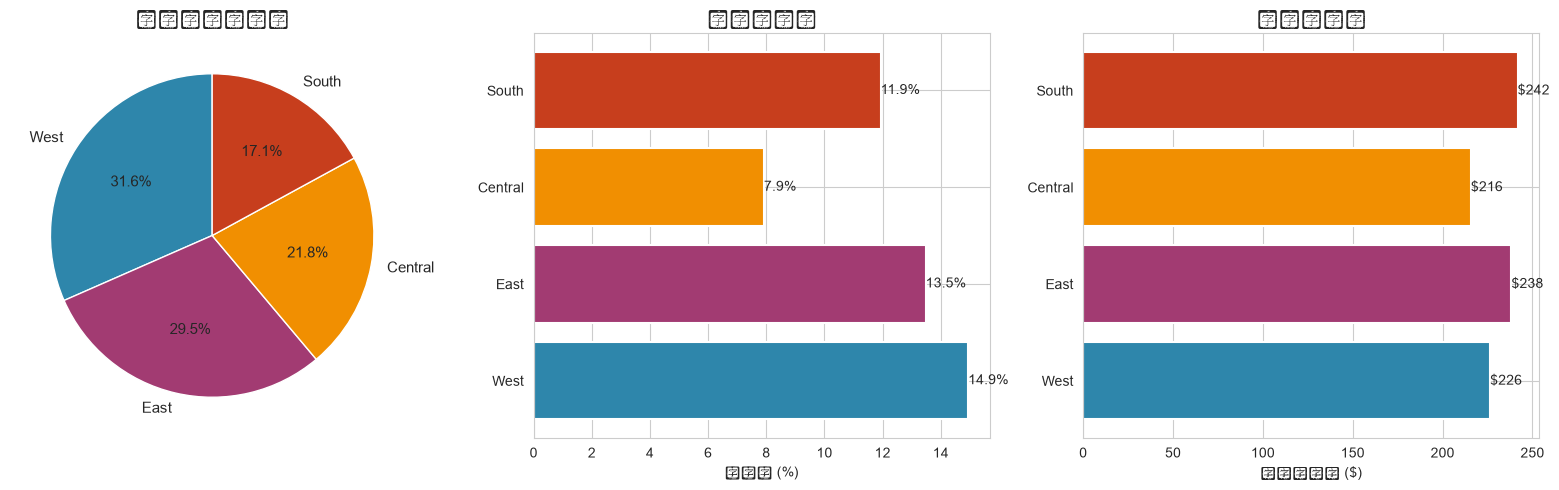

In [4]:
# 区域对比可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 销售额占比
colors_pie = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
wedges, texts, autotexts = axes[0].pie(
    region_stats['Total Sales'], 
    labels=region_stats['Region'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('区域销售额占比', fontsize=14, fontweight='bold')

# 利润率对比
bars = axes[1].barh(region_stats['Region'], region_stats['Profit Margin'], 
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('利润率 (%)')
axes[1].set_title('区域利润率', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=10)

# 客单价对比
bars = axes[2].barh(region_stats['Region'], region_stats['Avg Sales'],
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[2].set_xlabel('平均销售额 ($)')
axes[2].set_title('区域客单价', fontsize=14, fontweight='bold')
axes[2].bar_label(bars, fmt='$%.0f', fontsize=10)

plt.tight_layout()
plt.show()

## 2. 州（State）维度分析

In [5]:
# Top 15 州销售额
state_sales = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
state_sales['Profit Margin'] = (state_sales['Profit'] / state_sales['Sales'] * 100).round(2)
state_sales = state_sales.sort_values('Sales', ascending=False)

top15_states = state_sales.head(15)

print('='*60)
print('📊 Top 15 州销售额')
print('='*60)
print(top15_states.to_string(index=False))

📊 Top 15 州销售额
         State       Sales      Profit  Profit Margin
    California 457687.6315  76381.3871          16.69
      New York 310876.2710  74038.5486          23.82
         Texas 170188.0458 -25729.3563         -15.12
    Washington 138641.2700  33402.6517          24.09
  Pennsylvania 116511.9140 -15559.9603         -13.35
       Florida  89473.7080  -3399.3017          -3.80
      Illinois  80166.1010 -12607.8870         -15.73
          Ohio  78258.1360 -16971.3766         -21.69
      Michigan  76269.6140  24463.1876          32.07
      Virginia  70636.7200  18597.9504          26.33
North Carolina  55603.1640  -7490.9122         -13.47
       Indiana  53555.3600  18382.9363          34.33
       Georgia  49095.8400  16250.0433          33.10
      Kentucky  36591.7500  11199.6966          30.61
    New Jersey  35764.3120   9772.9138          27.33


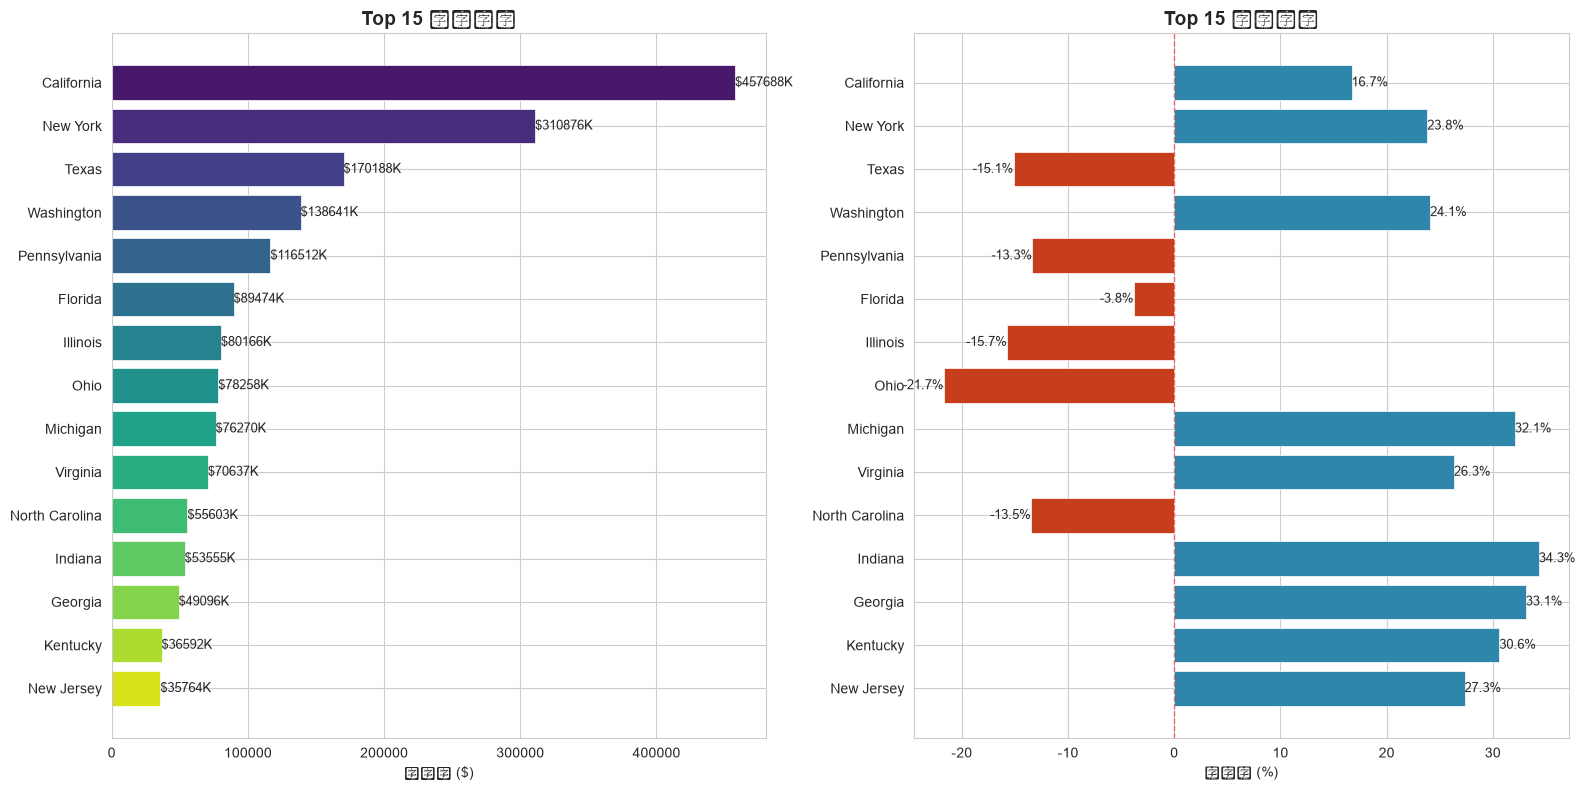

In [6]:
# Top 15 州可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 销售额柱状图
colors = sns.color_palette('viridis', 15)
bars = axes[0].barh(top15_states['State'].iloc[::-1], top15_states['Sales'].iloc[::-1],
                    color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('销售额 ($)')
axes[0].set_title('Top 15 州销售额', fontsize=14, fontweight='bold')
axes[0].bar_label(bars, fmt='$%.0fK', fontsize=9)

# 利润率柱状图
colors_margin = ['#2E86AB' if x > 0 else '#C73E1D' for x in top15_states['Profit Margin'].iloc[::-1]]
bars = axes[1].barh(top15_states['State'].iloc[::-1], top15_states['Profit Margin'].iloc[::-1],
                    color=colors_margin, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('利润率 (%)')
axes[1].set_title('Top 15 州利润率', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=9)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 3. 亏损州分析

⚠️ 亏损州统计
共 10 个州处于亏损状态

         State       Sales      Profit  Profit Margin
         Texas 170188.0458 -25729.3563         -15.12
          Ohio  78258.1360 -16971.3766         -21.69
  Pennsylvania 116511.9140 -15559.9603         -13.35
      Illinois  80166.1010 -12607.8870         -15.73
North Carolina  55603.1640  -7490.9122         -13.47
      Colorado  32108.1180  -6527.8579         -20.33
     Tennessee  30661.8730  -5341.6936         -17.42
       Arizona  35282.0010  -3427.9246          -9.72
       Florida  89473.7080  -3399.3017          -3.80
        Oregon  17431.1500  -1190.4705          -6.83


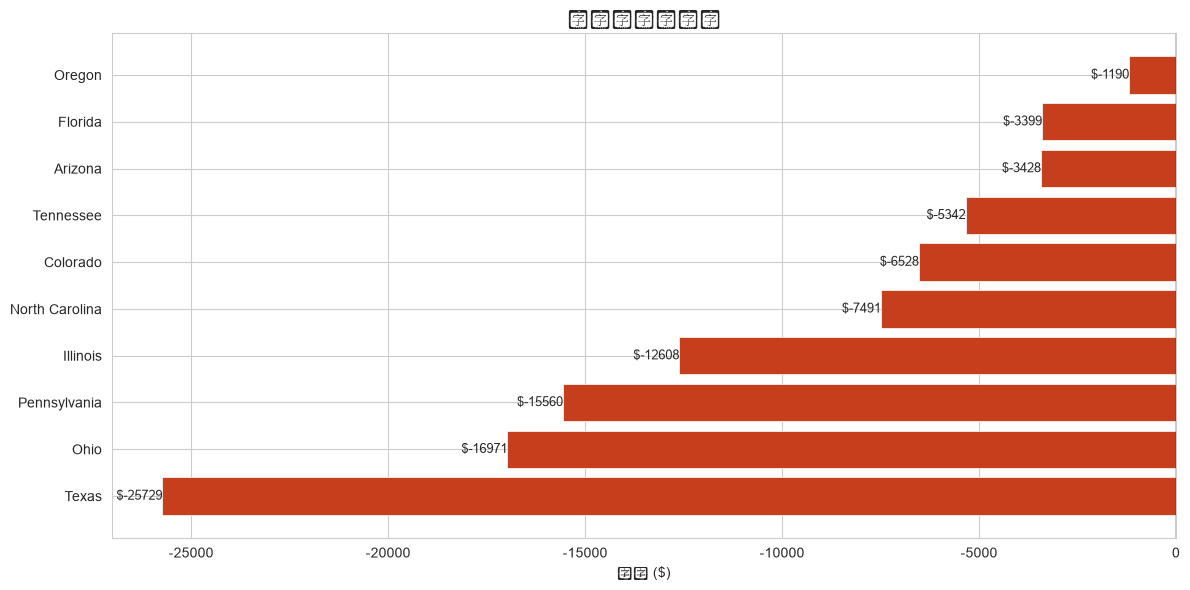

In [7]:
# 找出亏损的州
loss_states = state_sales[state_sales['Profit'] < 0].sort_values('Profit')

print('='*60)
print('⚠️ 亏损州统计')
print('='*60)
print(f'共 {len(loss_states)} 个州处于亏损状态')
print()
print(loss_states.to_string(index=False))

# 可视化
if len(loss_states) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#C73E1D' if x < 0 else '#2E86AB' for x in loss_states['Profit']]
    bars = ax.barh(loss_states['State'], loss_states['Profit'], 
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('利润 ($)')
    ax.set_title('亏损州利润分布', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.bar_label(bars, fmt='$%.0f', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. 城市（City）维度分析

In [8]:
# Top 10 城市
city_sales = df.groupby(['City', 'State']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
city_sales['Profit Margin'] = (city_sales['Profit'] / city_sales['Sales'] * 100).round(2)
city_sales = city_sales.sort_values('Sales', ascending=False)

top10_cities = city_sales.head(10)

print('='*60)
print('📊 Top 10 城市销售额')
print('='*60)
print(top10_cities.to_string(index=False))

📊 Top 10 城市销售额
         City        State       Sales      Profit  Order ID  Profit Margin
New York City     New York 256368.1610  62036.9837       450          24.20
  Los Angeles   California 175851.3410  30440.7579       384          17.31
      Seattle   Washington 119540.7420  29156.0967       212          24.39
San Francisco   California 112669.0920  17507.3854       265          15.54
 Philadelphia Pennsylvania 109077.0130 -13837.7674       265         -12.69
      Houston        Texas  64504.7604 -10153.5485       188         -15.74
      Chicago     Illinois  48539.5410  -6654.5688       171         -13.71
    San Diego   California  47521.0290   6377.1960        88          13.42
      Detroit     Michigan  42446.9440  13181.7908        53          31.05
 Jacksonville      Florida  39133.3280  -2445.6608        38          -6.25


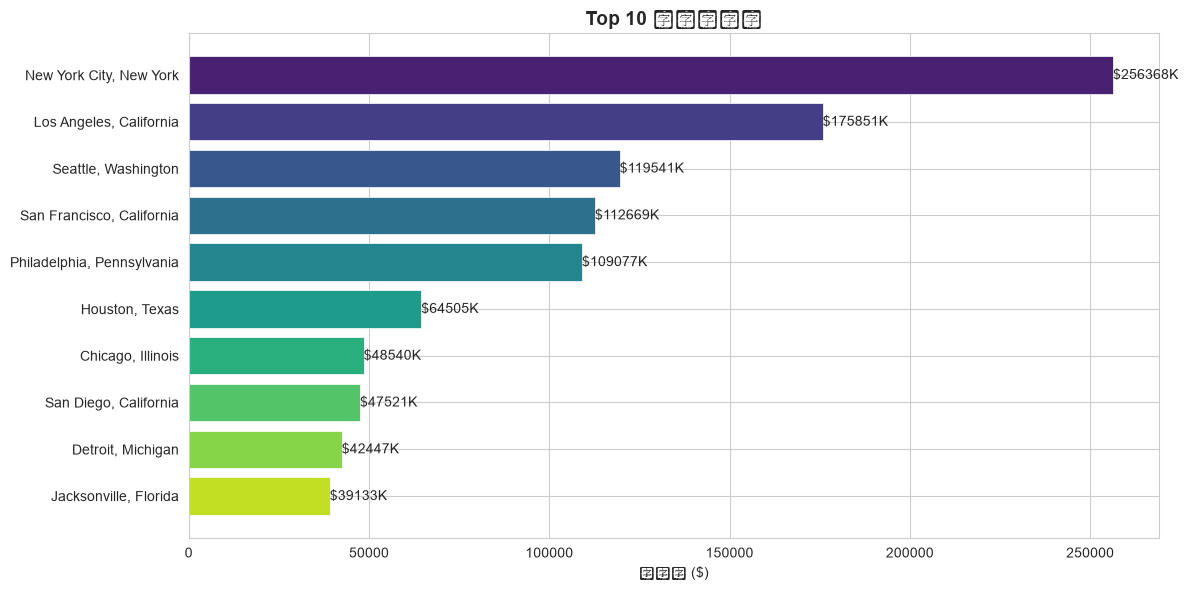

In [9]:
# Top 10 城市可视化
fig, ax = plt.subplots(figsize=(12, 6))

top10_cities['City_State'] = top10_cities['City'] + ', ' + top10_cities['State']
colors = sns.color_palette('viridis', 10)
bars = ax.barh(top10_cities['City_State'].iloc[::-1], top10_cities['Sales'].iloc[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('销售额 ($)')
ax.set_title('Top 10 城市销售额', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='$%.0fK', fontsize=10)

plt.tight_layout()
plt.show()

## 5. 区域×品类交叉分析

In [10]:
# 区域×品类交叉表
cross_region_category = df.groupby(['Region', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# 透视表
pivot_sales = cross_region_category.pivot(index='Region', columns='Category', values='Sales')
pivot_profit = cross_region_category.pivot(index='Region', columns='Category', values='Profit')

print('='*60)
print('📊 区域×品类销售额')
print('='*60)
print(pivot_sales.round(0).to_string())
print()
print('='*60)
print('📊 区域×品类利润')
print('='*60)
print(pivot_profit.round(0).to_string())

📊 区域×品类销售额
Category  Furniture  Office Supplies  Technology
Region                                          
Central    163797.0         167026.0    170416.0
East       208291.0         205516.0    264974.0
South      117299.0         125651.0    148772.0
West       252613.0         220853.0    251992.0

📊 区域×品类利润
Category  Furniture  Office Supplies  Technology
Region                                          
Central     -2871.0           8880.0     33697.0
East         3046.0          41015.0     47462.0
South        6771.0          19986.0     19992.0
West        11505.0          52610.0     44304.0


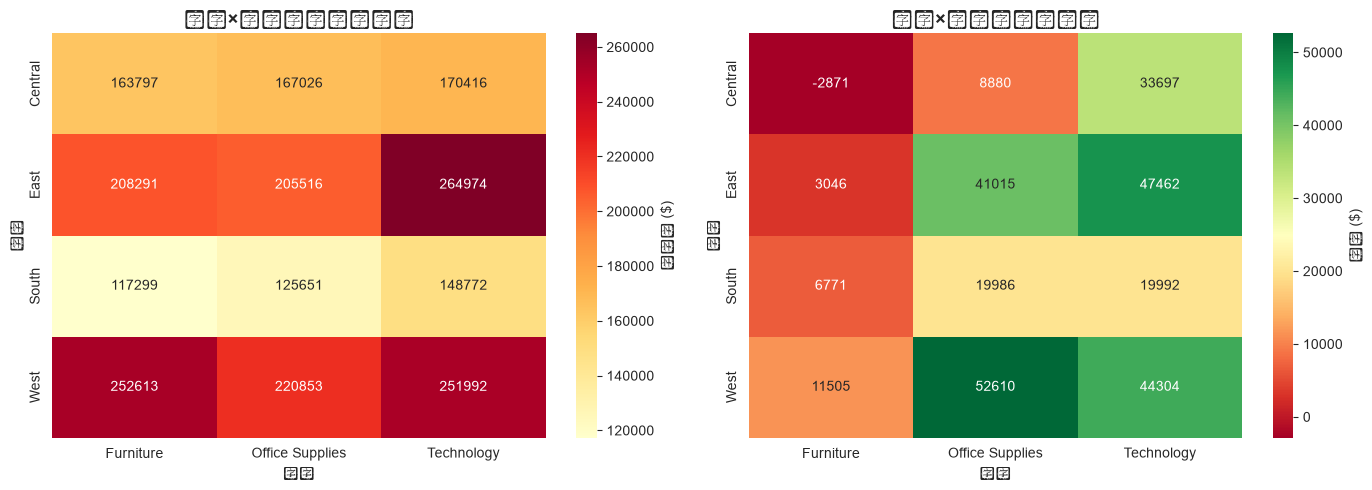

In [11]:
# 热力图可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 销售额热力图
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': '销售额 ($)'})
axes[0].set_title('区域×品类销售额热力图', fontsize=14, fontweight='bold')
axes[0].set_ylabel('区域')
axes[0].set_xlabel('品类')

# 利润热力图
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', 
            ax=axes[1], cbar_kws={'label': '利润 ($)'})
axes[1].set_title('区域×品类利润热力图', fontsize=14, fontweight='bold')
axes[1].set_ylabel('区域')
axes[1].set_xlabel('品类')

plt.tight_layout()
plt.show()

## 6. 交互式地图可视化

In [12]:
# 按州聚合数据用于地图
state_map_data = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
state_map_data['Profit Margin'] = (state_map_data['Profit'] / state_map_data['Sales'] * 100).round(2)

# 创建美国地图
fig = px.choropleth(
    state_map_data,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    hover_data=['Sales', 'Profit', 'Profit Margin'],
    color_continuous_scale='YlOrRd',
    title='美国各州销售额地图'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    height=500
)

fig.show()

## 7. 关键发现

In [13]:
# 计算关键指标
best_region = region_stats.iloc[0]
worst_region = region_stats.iloc[-1]
best_state = state_sales.iloc[0]
best_city = city_sales.iloc[0]

print('='*60)
print('💡 关键发现')
print('='*60)
print(f'\n🏆 最佳区域：{best_region["Region"]}')
print(f'   - 销售额：${best_region["Total Sales"]:,.2f}')
print(f'   - 占比：{best_region["Sales Share"]:.1f}%')
print(f'   - 利润率：{best_region["Profit Margin"]:.1f}%')

print(f'\n⚠️  待改进区域：{worst_region["Region"]}')
print(f'   - 销售额：${worst_region["Total Sales"]:,.2f}')
print(f'   - 占比：{worst_region["Sales Share"]:.1f}%')
print(f'   - 利润率：{worst_region["Profit Margin"]:.1f}%')

print(f'\n🥇 最佳州：{best_state["State"]}')
print(f'   - 销售额：${best_state["Sales"]:,.2f}')
print(f'   - 利润率：{best_state["Profit Margin"]:.1f}%')

print(f'\n🏙️  最佳城市：{best_city["City"]}, {best_city["State"]}')
print(f'   - 销售额：${best_city["Sales"]:,.2f}')
print(f'   - 利润率：{best_city["Profit Margin"]:.1f}%')

print(f'\n⚠️  亏损州数量：{len(loss_states)}')
if len(loss_states) > 0:
    print(f'   - 主要亏损州：{", ".join(loss_states["State"].head(3).tolist())}')

💡 关键发现

🏆 最佳区域：West
   - 销售额：$725,457.82
   - 占比：31.6%
   - 利润率：14.9%

⚠️  待改进区域：South
   - 销售额：$391,721.91
   - 占比：17.1%
   - 利润率：11.9%

🥇 最佳州：California
   - 销售额：$457,687.63
   - 利润率：16.7%

🏙️  最佳城市：New York City, New York
   - 销售额：$256,368.16
   - 利润率：24.2%

⚠️  亏损州数量：10
   - 主要亏损州：Texas, Ohio, Pennsylvania
